In [ ]:
import sys; sys.path.append('..')
import yaml

from simulator.loader import MarketDataLoader
from simulator.hmm import HybridJumpsHMM
from simulator.single_index import SingleIndexModel

# 1. Load configuration
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

market_ticker = str(config["data"]["market_ticker"])
stock_tickers = list(config["data"]["stock_tickers"])

# 2. Fetch Historical Data
print(f"Fetching data for {market_ticker} and {len(stock_tickers)} stocks...")
loader = MarketDataLoader(
    tickers=[market_ticker] + stock_tickers,
    start_date=config["data"]["start_date"], 
    end_date=config["data"]["end_date"]
)
data = loader.fetch_data()

# 3. HMM Grid Search Calibration
print("\nRunning FULL HMM Calibration (This will take a few minutes)...")
hmm = HybridJumpsHMM(n_states=config["hmm"]["n_states"])
hmm.fit(data[market_ticker])

grid_cfg = config["hmm"]["grid_search"]
best_eps, best_lambd = hmm.grid_search(
    data[market_ticker], 
    max_lag=grid_cfg["max_lag"], 
    n_paths=grid_cfg["n_paths"]
)
print(f"Calibration Complete! Best Epsilon: {best_eps}, Best Lambda: {best_lambd}")

# 4. Fit Single Index Model for stock simulation
sim_model = SingleIndexModel(tickers=stock_tickers)
sim_model.fit(data[stock_tickers], data[market_ticker])
print("Single Index Model fitted successfully.")

Fetching data for SPY and 50 stocks...

Running FULL HMM Calibration (This will take a few minutes)...
Calibration Complete! Best Epsilon: 0.00025, Best Lambda: 160
Single Index Model fitted successfully.


In [2]:
# ---------------------------------------------------------
# Monte Carlo Engine (Dual Simulator)
# ---------------------------------------------------------
NUM_PATHS = 50
n_steps = config["hmm"]["simulation"]["n_steps"]

print(f"Generating {NUM_PATHS} paths (10 years each) for Fidelity and Stress simulators...")

fidelity_sim_stocks = []
stress_sim_stocks = []

for i in range(NUM_PATHS):
    if i % 10 == 0:
        print(f"Processing path {i}/{NUM_PATHS}...")
        
    # Simulator A: Fidelity-Calibrated (No Jumps -> epsilon=0.0)
    states_fid = hmm.simulate_states(n_steps, epsilon=0.0, lambd=0.0)
    stocks_fid = sim_model.simulate(hmm.decode_states(states_fid))
    fidelity_sim_stocks.append(stocks_fid)
    
    # Simulator B: Stress-Augmented (Poisson Jumps -> epsilon=best_eps)
    states_stress = hmm.simulate_states(n_steps, epsilon=best_eps, lambd=best_lambd)
    stocks_stress = sim_model.simulate(hmm.decode_states(states_stress))
    stress_sim_stocks.append(stocks_stress)

print("Monte Carlo generation complete!")

Generating 50 paths (10 years each) for Fidelity and Stress simulators...
Processing path 0/50...
Processing path 10/50...
Processing path 20/50...
Processing path 30/50...
Processing path 40/50...
Monte Carlo generation complete!


In [ ]:
# ---------------------------------------------------------
# Advanced Metrics Engine (Multi-Core Fix)
# ---------------------------------------------------------
import multiprocessing
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from evaluate_utils import evaluate_path

num_cores = multiprocessing.cpu_count()
print(f"Distributing 246,000 optimizations across {num_cores} CPU cores...")

# Bundle the data with the config for the background workers
fid_args = [(p, config) for p in fidelity_sim_stocks]
stress_args = [(p, config) for p in stress_sim_stocks]

print("Evaluating Fidelity Simulator (Simulator A)...")
with ProcessPoolExecutor(max_workers=num_cores) as executor:
    fidelity_results = pd.DataFrame(list(executor.map(evaluate_path, fid_args)))

print("Evaluating Stress Simulator (Simulator B)...")
with ProcessPoolExecutor(max_workers=num_cores) as executor:
    stress_results = pd.DataFrame(list(executor.map(evaluate_path, stress_args)))

print("\n--- FIDELITY (NO JUMPS) AVERAGES ---")
print(fidelity_results.mean().round(2))
print("\n--- STRESS (POISSON JUMPS) AVERAGES ---")
print(stress_results.mean().round(2))

Distributing 246,000 optimizations across 8 CPU cores...
Evaluating Fidelity Simulator (Simulator A)...
Evaluating Stress Simulator (Simulator B)...

--- FIDELITY (NO JUMPS) AVERAGES ---
Gross Return (x)      15.02
Net Return (x)        13.11
Net Sharpe             0.98
Max Drawdown (%)     -36.05
Daily Turnover (%)    11.59
dtype: float64

--- STRESS (POISSON JUMPS) AVERAGES ---
Gross Return (x)      12.34
Net Return (x)        10.75
Net Sharpe             0.83
Max Drawdown (%)     -44.13
Daily Turnover (%)    11.72
dtype: float64


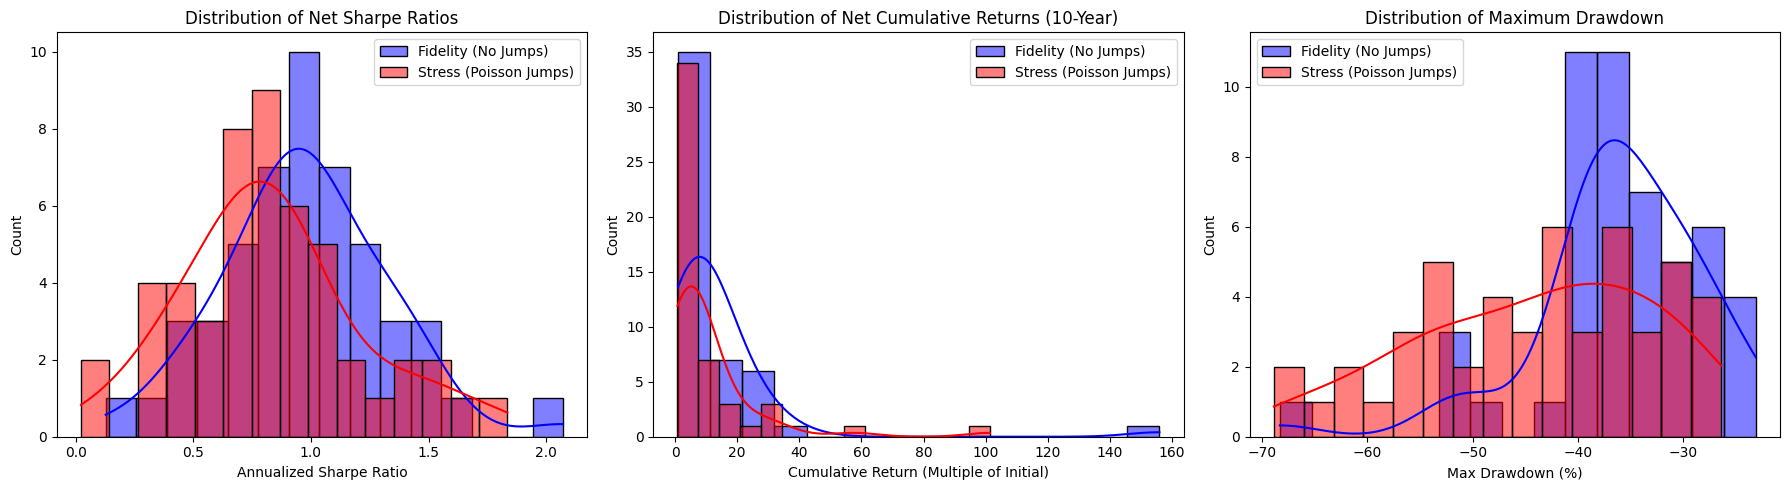

In [5]:
# ---------------------------------------------------------
# Cell 4: Distribution Visualization (Type-Safe)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Net Sharpe Distribution
sns.histplot(data=fidelity_results, x="Net Sharpe", color="blue", label="Fidelity (No Jumps)", kde=True, ax=axes[0], alpha=0.5, bins=15)
sns.histplot(data=stress_results, x="Net Sharpe", color="red", label="Stress (Poisson Jumps)", kde=True, ax=axes[0], alpha=0.5, bins=15)
axes[0].set_title("Distribution of Net Sharpe Ratios")
axes[0].set_xlabel("Annualized Sharpe Ratio")
axes[0].legend()

# Plot Net Return Distribution
sns.histplot(data=fidelity_results, x="Net Return (x)", color="blue", label="Fidelity (No Jumps)", kde=True, ax=axes[1], alpha=0.5, bins=15)
sns.histplot(data=stress_results, x="Net Return (x)", color="red", label="Stress (Poisson Jumps)", kde=True, ax=axes[1], alpha=0.5, bins=15)
axes[1].set_title("Distribution of Net Cumulative Returns (10-Year)")
axes[1].set_xlabel("Cumulative Return (Multiple of Initial)")
axes[1].legend()

# Plot Max Drawdown Distribution
sns.histplot(data=fidelity_results, x="Max Drawdown (%)", color="blue", label="Fidelity (No Jumps)", kde=True, ax=axes[2], alpha=0.5, bins=15)
sns.histplot(data=stress_results, x="Max Drawdown (%)", color="red", label="Stress (Poisson Jumps)", kde=True, ax=axes[2], alpha=0.5, bins=15)
axes[2].set_title("Distribution of Maximum Drawdown")
axes[2].set_xlabel("Max Drawdown (%)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
# ---------------------------------------------------------
# Sensitivity Analysis
# ---------------------------------------------------------
import time
import pandas as pd
from experts.markowitz import MarkowitzExpert

# We use just ONE stress path for the sensitivity sweep to save time
path = stress_sim_stocks[0]
windows = [30, 60, 90]
aversions = [0.1, 1.0, 3.0]

print("Running Sensitivity Analysis...")
start_time = time.time()
results = []

for w in windows:
    for gamma in aversions:
        # Initialize Expert with varied parameters
        expert = MarkowitzExpert(
            risk_aversion=gamma,
            rolling_window=w,
            max_weight=config["expert"]["max_weight"],
            annual_risk_free_rate=config["expert"]["annual_risk_free_rate"]
        )
        
        # Generate weights
        weights_df = expert.generate_labels(path)
        
        # Calculate boundaries hit
        # (Exclude the last column which is Cash, since Cash has a 100% cap, not 20%)
        risky_weights = weights_df.iloc[:, :-1]
        total_allocations = risky_weights.shape[0] * risky_weights.shape[1] 
        
        # How often did it hit the 0% floor? (adding tiny tolerance for float math)
        floor_hits = (risky_weights <= 0.0001).sum().sum()
        # How often did it hit the 20% cap?
        cap_hits = (risky_weights >= (config["expert"]["max_weight"] - 0.0001)).sum().sum()
        
        floor_pct = (floor_hits / total_allocations) * 100
        cap_pct = (cap_hits / total_allocations) * 100
        
        results.append({
            "Window": w,
            "Risk Aversion": gamma,
            "0% Floor Hits (%)": floor_pct,
            "20% Cap Hits (%)": cap_pct
        })
        print(f"Done: Window={w}, Gamma={gamma}")

end_time = time.time()
print(f"Finished in {int(end_time - start_time)} seconds.")

sensitivity_df = pd.DataFrame(results)
print("\n--- SENSITIVITY RESULTS ---")
print(sensitivity_df.to_string(index=False))

Running Sensitivity Analysis...
Done: Window=30, Gamma=0.1
Done: Window=30, Gamma=1.0
Done: Window=30, Gamma=3.0
Done: Window=60, Gamma=0.1
Done: Window=60, Gamma=1.0
Done: Window=60, Gamma=3.0
Done: Window=90, Gamma=0.1
Done: Window=90, Gamma=1.0
Done: Window=90, Gamma=3.0
Finished in 485 seconds.

--- SENSITIVITY RESULTS ---
 Window  Risk Aversion  0% Floor Hits (%)  20% Cap Hits (%)
     30            0.1          86.053012          6.568675
     30            1.0          86.020884          6.439357
     30            3.0          85.934137          6.217671
     60            0.1          84.933333          5.898374
     60            1.0          84.755285          5.721951
     60            3.0          84.745528          5.407317
     90            0.1          84.467490          5.583539
     90            1.0          84.292181          5.432922
     90            3.0          83.997531          5.040329
